## 3D vectors of label words using PCA

Fill out label, iteration and window size for data

Uses /data/iterative_vectors_original/ to generate vectors

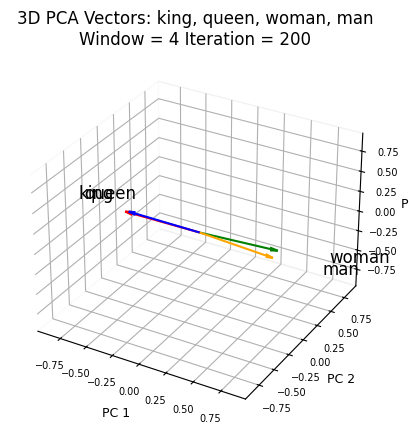

In [ ]:
import json
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

labels = ["king", "queen", "woman", "man"]
iteration = 200
window = 4


def plot(labels, vector_file_path, output_filepath):
    if not os.path.exists(vector_file_path):
        print(f"Error: Vector file not found at {vector_file_path}")
        return

    with open(vector_file_path, 'r') as f:
        all_vectors = json.load(f)

    # Extract vectors for the specified labels
    filtered_vectors = []
    for name in labels:
        if name in all_vectors:
            filtered_vectors.append(np.array(all_vectors[name]))
        else:
            print(f"Warning: Word '{name}' not found in {vector_file_path}")
            # If a word is not found, we can append a zero vector or skip it.
            # For now, let's skip it to avoid plotting issues.

    if not filtered_vectors:
        print("No vectors to plot after filtering.")
        return

    flattened = np.array(filtered_vectors)

    pca = PCA(n_components=3)
    vectors = pca.fit_transform(flattened)

    # Create a 3D figure
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.xaxis.pane.set_facecolor((1.0, 1.0, 1.0, 1.0))  # white
    ax.yaxis.pane.set_facecolor((1.0, 1.0, 1.0, 1.0))
    ax.zaxis.pane.set_facecolor((1.0, 1.0, 1.0, 1.0))
    
    origin = np.zeros(3)
    colors = {labels[0]: "red", labels[1]: "blue", labels[2]: "green", labels[3]: "orange"}

    index = 0
    vec_mag = 0
    for vec in vectors:
        ax.quiver(
            origin[0], origin[1], origin[2],
            vec[0], vec[1], vec[2],
            color=colors[labels[index]], length=1.0, normalize=False, arrow_length_ratio=0.1
        )
        ax.text(vec[0] * 1.65, vec[1] * 1.65, vec[2] * 1.65, labels[index], color='black', fontsize=12)
        index += 1
        if vec_mag < np.linalg.norm(vec):
            vec_mag = np.linalg.norm(vec)
        else:
            continue

    ax.set_xlim(-vec_mag - 0.25, vec_mag + 0.25)
    ax.set_ylim(-vec_mag - 0.25, vec_mag + 0.25)
    ax.set_zlim(-vec_mag - 0.25, vec_mag + 0.25)

    ax.tick_params(labelsize=7) 

    ax.set_xlabel('PC 1', fontsize=9)
    ax.set_ylabel('PC 2', fontsize=9)
    ax.set_zlabel('PC 3', fontsize=9)
    title = f"3D PCA Vectors: {', '.join(labels)}"
    subtitle = f"Window = {window} Iteration = {iteration}"
    ax.set_title(f"{title}\n{subtitle}", fontsize=12)

    plt.savefig(output_filepath, dpi = 300)
    plt.show()


if __name__ == "__main__":


    vector_file_name = f'window_{window}_iter_{iteration}.json'
    vector_file_path = os.path.join('data/iterative_vectors_original', vector_file_name)

    #output_filename = f"3D_Plot_win{window}_iter{iteration}.png"
    #output_dir = "plots"
    #os.makedirs(output_dir, exist_ok=True)
    #full_output_path = os.path.join(output_dir, output_filename)

    prefix = ''.join([w[0] for w in labels])
    full_output_path = f"results/plots/{prefix}_3D_Plot_window_{window}_iteration_{iteration}.png"

    plot(labels, vector_file_path, full_output_path)
